In [18]:
import json 
import os 
import glob 
import pandas as pd 

In [19]:
src_dir = './'

annotation_files = glob.glob(os.path.join(src_dir , '*' , '*' , '*.json'))
annotation_files[:5]

['./mapa/typeS/mapa7010_H93-p35.json',
 './mapa/typeS/mapa7010_M78-p21.json',
 './mapa/typeS/mapa7010_H21-p29.json',
 './mapa/typeS/mapa7010_M28-p17.json',
 './mapa/typeU/mapa7010_H93-p35.json']

In [20]:
annotation_data = [json.load(open(annotation_file)) for annotation_file in annotation_files]

In [21]:
anno_df = pd.DataFrame(annotation_data)
anno_df

,sample_steps,fname,stage,run,user,notes,reject,correctness,understand,quality
0,"[{'step': '93', 'target': 'r3c2', 'value': 'un...",H93-p35.json,typeS,annotate,mapa7010,,understandable,5,5,[1]
1,"[{'step': '78', 'target': 'r3c9', 'value': 'un...",M78-p21.json,typeS,annotate,mapa7010,The explanation is repeated twice with one ver...,understandable,3,3,[5]
2,"[{'step': '21', 'target': 'r1c5', 'value': 'un...",H21-p29.json,typeS,annotate,mapa7010,The statement in the first step - (unshaded ce...,understandable,3,5,[]
3,"[{'step': '28', 'target': 'r5c6', 'value': 'sh...",M28-p17.json,typeS,annotate,mapa7010,Explanation could be more explicit about cell ...,understandable,5,5,[]
4,"[{'target': 'r3c2', 'value': 'unshaded', 'unsh...",H93-p35.json,typeU,annotate,mapa7010,Step #3 doesn't make any sense in multiple ways.,understandable,1,3,[]
5,"[{'target': 'r1c5', 'value': 'unshaded', 'unsh...",H21-p29.json,typeU,annotate,mapa7010,"The explanation flows well and is correct, but...",understandable,5,5,[]
6,"[{'target': 'r5c6', 'value': 'shaded', 'unshad...",M28-p17.json,typeU,annotate,mapa7010,Steps are unhelpful and somewhat repetitive. N...,understandable,1,1,[]
7,"[{'step': '28', 'target': 'r5c6', 'value': 'sh...",M28-p17.json,typeS,annotate,roda9210,,understandable,5,5,[]
8,"[{'step': '21', 'target': 'r1c5', 'value': 'un...",H21-p29.json,typeS,annotate,roda9210,Bad sentence construction when explaining the ...,understandable,3,5,[1]
9,"[{'step': '1', 'target': 'r2c3', 'value': 'uns...",S1-p13.json,typeS,annotate,roda9210,,understandable,1,3,[]


## Analysis 


- Kripendoff-Alpha: Between Annotators for 
    - Ordinal for Factuality/Understanding ✅
        - Make sure that your scale is off by one - does not differ by 2 points 
    - Nominal for QA

- Average Performance 
    - Average per puzzle
    - Average per difficulty 
    - Average across all puzzles ✅
    - Average across staging ✅

In [ ]:
map = {1:1, 3:2, 5:3}

anno_df['correctness'] = anno_df['correctness'].map(int).map(map)
anno_df['understand'] = anno_df[target_col].map(int).map(map)
anno_df['doc_ids'] = anno_df['fname'] + anno_df['stage']
anno_df

,sample_steps,fname,stage,run,user,notes,reject,correctness,understand,quality,doc_ids
0,"[{'step': '93', 'target': 'r3c2', 'value': 'un...",H93-p35.json,typeS,annotate,mapa7010,,understandable,3,3,[1],H93-p35.jsontypeS
1,"[{'step': '78', 'target': 'r3c9', 'value': 'un...",M78-p21.json,typeS,annotate,mapa7010,The explanation is repeated twice with one ver...,understandable,2,2,[5],M78-p21.jsontypeS
2,"[{'step': '21', 'target': 'r1c5', 'value': 'un...",H21-p29.json,typeS,annotate,mapa7010,The statement in the first step - (unshaded ce...,understandable,2,3,[],H21-p29.jsontypeS
3,"[{'step': '28', 'target': 'r5c6', 'value': 'sh...",M28-p17.json,typeS,annotate,mapa7010,Explanation could be more explicit about cell ...,understandable,3,3,[],M28-p17.jsontypeS
4,"[{'target': 'r3c2', 'value': 'unshaded', 'unsh...",H93-p35.json,typeU,annotate,mapa7010,Step #3 doesn't make any sense in multiple ways.,understandable,1,2,[],H93-p35.jsontypeU
5,"[{'target': 'r1c5', 'value': 'unshaded', 'unsh...",H21-p29.json,typeU,annotate,mapa7010,"The explanation flows well and is correct, but...",understandable,3,3,[],H21-p29.jsontypeU
6,"[{'target': 'r5c6', 'value': 'shaded', 'unshad...",M28-p17.json,typeU,annotate,mapa7010,Steps are unhelpful and somewhat repetitive. N...,understandable,1,1,[],M28-p17.jsontypeU
7,"[{'step': '28', 'target': 'r5c6', 'value': 'sh...",M28-p17.json,typeS,annotate,roda9210,,understandable,3,3,[],M28-p17.jsontypeS
8,"[{'step': '21', 'target': 'r1c5', 'value': 'un...",H21-p29.json,typeS,annotate,roda9210,Bad sentence construction when explaining the ...,understandable,2,3,[1],H21-p29.jsontypeS
9,"[{'step': '1', 'target': 'r2c3', 'value': 'uns...",S1-p13.json,typeS,annotate,roda9210,,understandable,1,2,[],S1-p13.jsontypeS


In [23]:
import krippendorff 
import numpy as np 

In [24]:
(anno_df[(anno_df['user'] == 'Mary') & (anno_df['fname'] == 'lala')]).empty

True

In [27]:
doc_col = 'doc_ids'
user_col = 'user'
anno_col = 'correctness'


mini_anno_df = anno_df[[doc_col , user_col , anno_col]]

unique_docs = mini_anno_df[doc_col].unique()
unique_users = mini_anno_df[user_col].unique()

# anno_array = np.empty((len(unique_docs) , len(unique_users)))
anno_array = np.empty((len(unique_users) , len(unique_docs)))
anno_array[:] = np.nan 


for i , user in enumerate(unique_users) : 
    for j , fname in enumerate(unique_docs) : 

        if not mini_anno_df[(mini_anno_df[user_col] == user) & (mini_anno_df[doc_col] == fname)].empty : 
            try : 
                anno_array[i , j] = mini_anno_df[(mini_anno_df[user_col] == user) & (mini_anno_df[doc_col] == fname)][anno_col].item() 
            except : 
                print(mini_anno_df[(mini_anno_df[user_col] == user) & (mini_anno_df[doc_col] == fname)])
                break






anno_array



array([[ 3.,  2.,  2.,  3.,  1.,  3.,  1., nan, nan, nan, nan],
       [ 3.,  1.,  2.,  3.,  1.,  3.,  3.,  1.,  1.,  3., nan],
       [ 3., nan,  3.,  3.,  1.,  3.,  3., nan,  1.,  1., nan],
       [ 3., nan,  3., nan,  1.,  3.,  3., nan,  1.,  2.,  1.]])

In [28]:
alpha = krippendorff.alpha(reliability_data=anno_array, 
                           level_of_measurement='ordinal')

In [29]:
alpha

0.6415770609318996

In [ ]:
doc_col = 'doc_ids'
user_col = 'user'
anno_col = target_col


mini_anno_df = anno_df[[doc_col , user_col , anno_col]]

unique_docs = mini_anno_df[doc_col].unique()
unique_users = mini_anno_df[user_col].unique()

# anno_array = np.empty((len(unique_docs) , len(unique_users)))
anno_array = np.empty((len(unique_users) , len(unique_docs)))
anno_array[:] = np.nan 


for i , user in enumerate(unique_users) : 
    for j , fname in enumerate(unique_docs) : 

        if not mini_anno_df[(mini_anno_df[user_col] == user) & (mini_anno_df[doc_col] == fname)].empty : 
            try : 
                anno_array[i , j] = mini_anno_df[(mini_anno_df[user_col] == user) & (mini_anno_df[doc_col] == fname)][anno_col].item() 
            except : 
                print(mini_anno_df[(mini_anno_df[user_col] == user) & (mini_anno_df[doc_col] == fname)])
                break



alpha = krippendorff.alpha(reliability_data=anno_array, 
                           level_of_measurement='ordinal')
alpha

0.2700215053763442

In [ ]:
# staging

In [ ]:
staged_anno_df = anno_df[anno_df['stage'] == 'typeS']
unstaged_anno_df = anno_df[anno_df['stage'] == 'typeU']

print(staged_anno_df['correctness'].mean() , unstaged_anno_df['correctness'].mean())
print(staged_anno_df['understand'].mean() , unstaged_anno_df['understand'].mean())


2.5 1.894736842105263
2.7142857142857144 2.1052631578947367


In [37]:
anno_df['correctness'].mean() 

2.1515151515151514

In [38]:
anno_df['understand'].mean() 

2.3636363636363638

---

In [45]:
import matplotlib.pyplot as plt 

In [ ]:
target_col = 'under'

In [ ]:
avg = anno_df.groupby('doc_ids')[target_col].mean().to_dict()

ops = {}

for k , v in avg.items() : 

    puzz_id , stage = k.split('.json')
    
    if puzz_id in ops : 
        ops[puzz_id][stage] = v 
    else : 
        ops[puzz_id] = {stage : v}

d =  pd.DataFrame(ops).T
d['Total'] = d.sum(axis=1)
d = d.sort_values(by='Total', ascending=False).drop(columns='Total')

d

,typeS,typeU
H21-p29,2.5,3.0
M28-p17,3.0,2.5
H93-p35,3.0,1.0
M78-p21,1.5,2.0
S1-p13,1.0,1.0
S172-p36,NaN,1.0


In [91]:
avg = anno_df.groupby('doc_ids')[target_col].count()

ops = {}

for k , v in avg.items() : 

    puzz_id , stage = k.split('.json')
    
    if puzz_id in ops : 
        ops[puzz_id][stage] = v 
    else : 
        ops[puzz_id] = {stage : v}

df = pd.DataFrame(ops).T.fillna(0)

labels = df['typeS'].to_list() + df['typeU'].to_list()
labels

[4.0, 4.0, 3.0, 2.0, 1.0, 0.0, 4.0, 4.0, 4.0, 3.0, 3.0, 1.0]

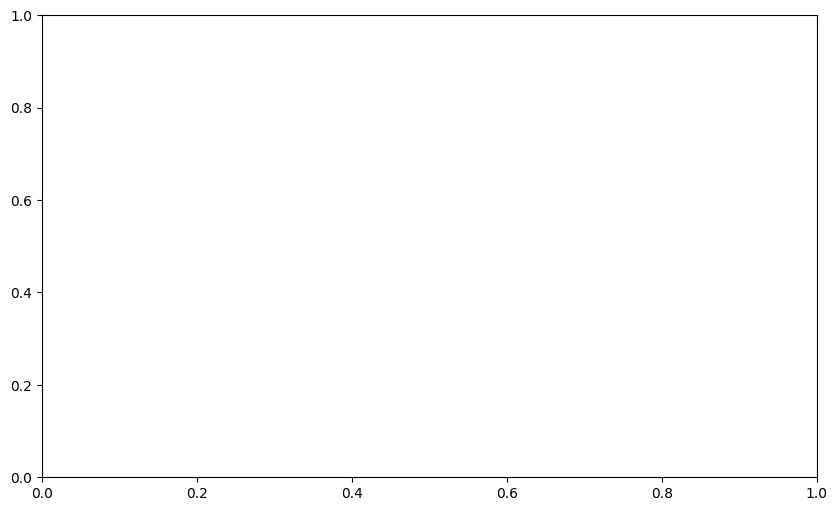

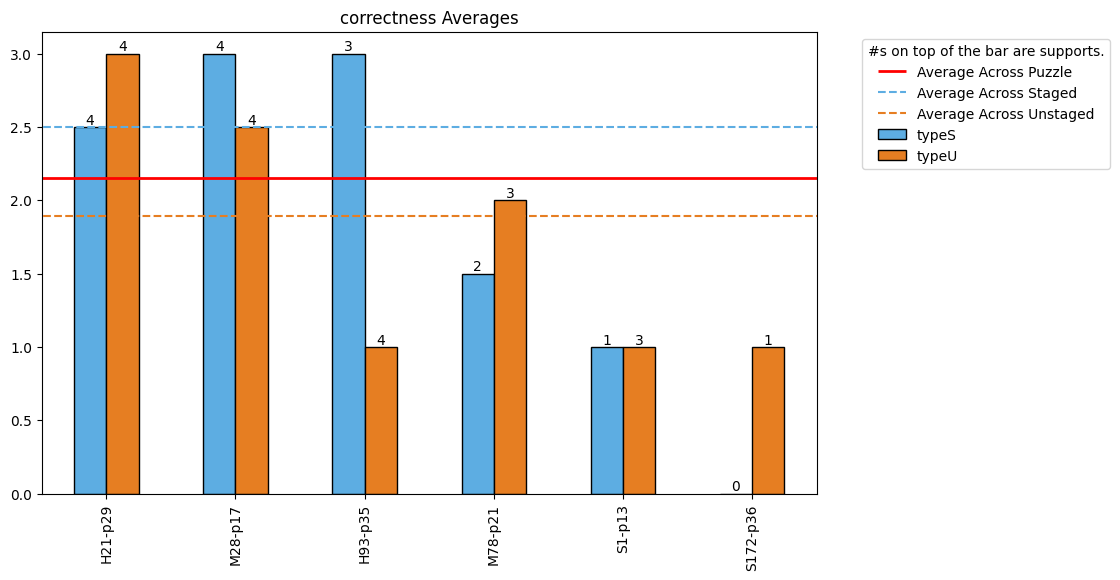

In [93]:
fig, ax = plt.subplots(figsize=(10, 6))

ax = d.plot(kind='bar', figsize=(10, 6), color=['#5DADE2', '#E67E22'], edgecolor='black')

ax.hlines(y=anno_df[target_col].mean() ,xmin=-1 , xmax=10 , linestyles='solid' , linewidth=2, colors='red' , label='Average Across Puzzle')
ax.hlines(y=staged_anno_df[target_col].mean() ,xmin=-1 , xmax=10 ,linestyles='--' , colors='#5DADE2', label='Average Across Staged')
ax.hlines(y=unstaged_anno_df[target_col].mean() ,xmin=-1 , xmax=10 , linestyles='--' , colors='#E67E22', label='Average Across Unstaged')

for patch , label in zip(ax.patches, labels) : 

    height = patch.get_height()
    width = patch.get_width()
    x_pos = patch.get_x()

    ax.text(x_pos + width/2, height, f'{int(label)}', 
            ha='center', va='bottom', fontsize=10)
    
ax.set_title(f"{target_col} Averages")
ax.legend(title="#s on top of the bar are supports.", loc='upper left', bbox_to_anchor=(1.05, 1))